#### Link Tableu :

- Dashboard Full : https://public.tableau.com/views/P1M2_rofiah-budi/DashboardFull?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

- Story : https://public.tableau.com/views/P1M2_rofiah-budi/Story1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

### i. Perkenalan

Milestone 2

Nama : Rofi'ah Budi Nadia
Batch : CODA-RMT-019

Program ini dibuat untuk mengevaluasi pembelajaran pada Hacktiv8 Comprehensive Data Analytics Program khususnya pada Phase 1 mengenai pemahaman statistik deskriptif, statistik inferensial dan visualisasi data.

### ii. Identifikasi Masalah

- Latar belakang : Toko yang berbasis di London ini telah menjual hadiah dan perlengkapan rumah tangga untuk orang dewasa dan anak-anak melalui situs webnya sejak tahun 2007. Pelanggan mereka berasal dari seluruh dunia dan biasanya melakukan pembelian langsung untuk keperluan pribadi. Selain itu, terdapat pula usaha kecil yang membeli dalam jumlah besar dan menjualnya kembali kepada pelanggan lain melalui saluran ritel.

- Metode SMART:
  - S = Perusahaan ingin memperluas penjualan internasional secara merata
  - M = Membutuhkan insight mengenai apa saja faktor yang berpengaruh
  - A = Market saat ini sudah ke luar negeri hanya saja penjualan belum merata
  - R = Penjualan toko tersebut dapat merata ke luar negeri dan tidak terpusat di London (United KIngdom) saja
  - T = Dalam jangka waktu 5 tahun kedepan

- Problem statement : Perusahaan ingin memperluas penjualan internasional secara merata dalam 5 tahun kedepan, maka membutuhkan insight mengenai apa saja faktor yang berpengaruh agar penjualan tersebut dapat merata dan tidak terpusat di London saja.

- Penjabaran masalah :
  1. Setelah United Kingdom, negara mana dengan transaksi terbanyak?
  2. Produk apa yang paling banyak terjual?
  3. Produk apa yang paling sering di cancel?
  4. Berapa banyak transaksi yang di cancel pada bulan April?
  5. Pada hari apa rata-rata revenue terbesar? (Statistik Deskriptif)
  6. Apakah terdapat perbedaan secara signifikan rata-rata penghasil revenue di antara negara France, Germany dan Spain? (Statistik Inferensial)

### iii. Data Loading

Data source : https://www.kaggle.com/datasets/gabrielramos87/an-online-shop-business/data

#### Import Libraries

In [ ]:
import pandas as pd # untuk manipulasi data
import matplotlib.pyplot as plt # untuk visualisasi data
import seaborn as sns # untuk visualisasi data
from scipy import stats # library untuk analisis statistik

#### Data Loading

In [ ]:
df = pd.read_csv('sales.csv') # loading dataset
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


In [ ]:
df.info() # menampilkan infromasi dari data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


Data sales.csv memiliki beberapa informasi yaitu :
- memiliki 536350 baris dan 8 column
- dari column-column tersebut hanya column `CostumerNo` yang memiliki value null
- terdapat 5 column yang bertipe data object, 2 column bertipe data float, dan 1 column bertipe data integer

### iv. Data Cleaning

#### Missing Values

In [ ]:
df.isna().sum() # mengecek apakah ada value null pada setiap column

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,55
Country,0


Terdapat 55 value null pada column `CostumerNo`

In [ ]:
df = df.dropna() # menghapus rows pada column yang memiliki value null yaitu column 'CostumerNo'

In [ ]:
df.isna().sum() # mengecek kembali apakah masih ada value null

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,0
Country,0


Data sudah bersih dari missing value

#### Data Format

In [ ]:
df['Date'] = pd.to_datetime(df['Date']) # mengubah tipe data menjadi datetime

/tmp/ipykernel_2423/3465383485.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date']) # mengubah tipe data menjadi datetime


In [ ]:
df['Quantity'] = df['Quantity'].astype(int) # mengubah tipe data menjadi integer

/tmp/ipykernel_2423/2457375821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = df['Quantity'].astype(int) # mengubah tipe data menjadi integer


In [ ]:
df['CustomerNo'] = df['CustomerNo'].astype(str) # mengubah tipe data menjadi string

/tmp/ipykernel_2423/1110108112.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CustomerNo'] = df['CustomerNo'].astype(str) # mengubah tipe data menjadi string


In [ ]:
df['Revenue'] = df['Price'] * df['Quantity'] # membuat column baru yaitu Revenue dengan mengkalikan kolom Price dan Quantity

/tmp/ipykernel_2423/1226837680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue'] = df['Price'] * df['Quantity'] # membuat column baru yaitu Revenue dengan mengkalikan kolom Price dan Quantity


Kolom Revenue merupakan kolom baru yang dibutuhkan untuk proses analisis lebih lanjut

In [ ]:
# membuat fungsi is_cancellation() untuk mengelompokkan apakah suatu produk masuk ke kategori di cancel atau tidak
def is_cancellation(number):
  if number < 0:
    return True # true apabila produk di cancel
  else:
    return False # false apabila produk tidak di cancel

df['Cancellation'] = df['Quantity'].apply(is_cancellation) # membuat kolom baru yaitu Cancellation

/tmp/ipykernel_2423/124355739.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cancellation'] = df['Quantity'].apply(is_cancellation) # membuat kolom baru yaitu Cancellation


Kolom Cancellation bertipe data boolean dibutuhkan untuk proses analisis lebih lanjut

In [ ]:
df['Day'] = df['Date'].dt.day_name() # kolom Day berisi nama-nama hari pada transaksi
df['Month'] = df['Date'].dt.month_name() # kolom Month berisi nama-nama bulan pada transaksi
df['Year'] = df['Date'].dt.year.astype(str) # kolom year berisi tahun

/tmp/ipykernel_2423/2994653671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Day'] = df['Date'].dt.day_name() # kolom Day berisi nama-nama hari pada transaksi
/tmp/ipykernel_2423/2994653671.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month_name() # kolom Month berisi nama-nama bulan pada transaksi
/tmp/ipykernel_2423/2994653671.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

Membuat masing-masing kolom untuk `Day`, `Month`, dan `Year` untuk memudahkan dalam proses analisis

In [ ]:
df # melihat kembali dataframe

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue,Cancellation,Day,Month,Year
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,False,Monday,December,2019
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,False,Monday,December,2019
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36,False,Monday,December,2019
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80,False,Monday,December,2019
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64,False,Monday,December,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
536345,C536548,2018-12-01,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany,-37.92,True,Saturday,December,2018
536346,C536548,2018-12-01,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany,-42.27,True,Saturday,December,2018
536347,C536548,2018-12-01,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany,-11.74,True,Saturday,December,2018
536348,C536548,2018-12-01,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany,-65.40,True,Saturday,December,2018


Mengambil data dengan tahun 2019 saja, dan drop data dengan tahun 2018 agar tidak rancu.

In [ ]:
df = df[df['Date'].dt.year != 2018]

In [ ]:
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue,Cancellation,Day,Month,Year
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,False,Monday,December,2019
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,False,Monday,December,2019
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36,False,Monday,December,2019
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80,False,Monday,December,2019
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64,False,Monday,December,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494251,C540030,2019-01-04,22070,Small Red Retrospot Mug In Box,14.09,-24,16029.0,United Kingdom,-338.16,True,Friday,January,2019
494252,C540097,2019-01-04,22835,Hot Water Bottle I Am So Poorly,15.02,-4,15373.0,United Kingdom,-60.08,True,Friday,January,2019
494253,C540097,2019-01-04,22179,Set 10 Night Owl Lights,17.17,-4,15373.0,United Kingdom,-68.68,True,Friday,January,2019
494254,C540097,2019-01-04,22113,Grey Heart Hot Water Bottle,14.09,-4,15373.0,United Kingdom,-56.36,True,Friday,January,2019


#### Data Duplicate

In [ ]:
df.duplicated().sum() # mengecek apakah ada data yang duplicate

np.int64(4671)

Terdapat 5200 rows data yang duplicate, langkah selanjutnya yaitu di drop

In [ ]:
df.drop_duplicates() # membersihkan data yang duplicate

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue,Cancellation,Day,Month,Year
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,False,Monday,December,2019
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,False,Monday,December,2019
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36,False,Monday,December,2019
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80,False,Monday,December,2019
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64,False,Monday,December,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494251,C540030,2019-01-04,22070,Small Red Retrospot Mug In Box,14.09,-24,16029.0,United Kingdom,-338.16,True,Friday,January,2019
494252,C540097,2019-01-04,22835,Hot Water Bottle I Am So Poorly,15.02,-4,15373.0,United Kingdom,-60.08,True,Friday,January,2019
494253,C540097,2019-01-04,22179,Set 10 Night Owl Lights,17.17,-4,15373.0,United Kingdom,-68.68,True,Friday,January,2019
494254,C540097,2019-01-04,22113,Grey Heart Hot Water Bottle,14.09,-4,15373.0,United Kingdom,-56.36,True,Friday,January,2019


#### Outlier

Langkah selanjutnya yaitu menganalisis apakah ada outlier pada column `Price`, `Quantity`, dan `Revenue`. Apabila terdapat outlier maka kita akan handling outlier tersebut menggunakan methode IQR.

##### Column `Price`

<Axes: >

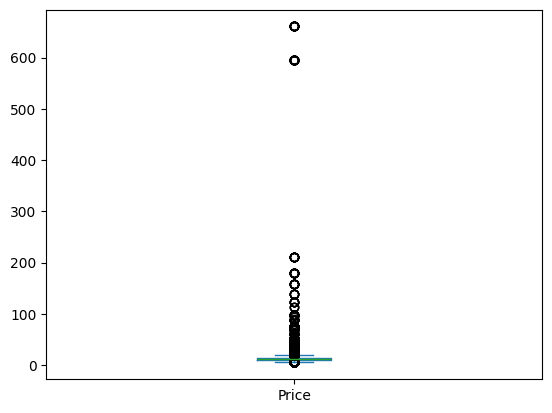

In [ ]:
df['Price'].plot(kind='box') # melihat dari visualisasi boxplot

Mengecek lower bound dan up boundary-nya

In [ ]:
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3-q1

up_bound = q3 + 1.5*iqr
low_bound = q1 - 1.5*iqr

print(f'Upper Boundary: {up_bound:.2f}' )
print(f'Lower Boundary: {low_bound:.2f}')

Upper Boundary: 18.84
Lower Boundary: 6.17


Handling outlier

In [ ]:
outlier_price = df['Price'][(df['Price']<low_bound) | (df['Price']>up_bound)]
print(f'Percentage of outliers: {len(outlier_price)*100/len(df['Price']):.2f}%%')

df['Price'] = df['Price'][(df['Price']>=low_bound) & (df['Price']<=up_bound)]

Percentage of outliers: 10.61%%


/tmp/ipykernel_2423/4180156042.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = df['Price'][(df['Price']>=low_bound) & (df['Price']<=up_bound)]


<Axes: >

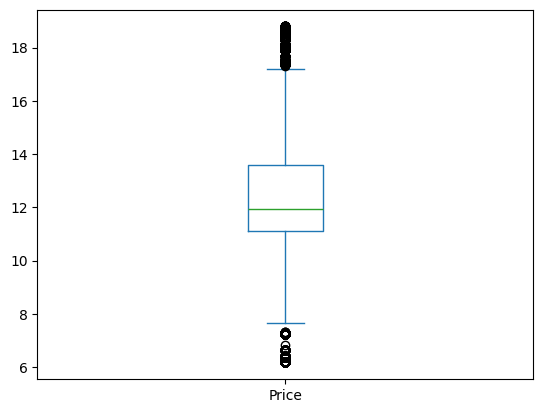

In [ ]:
df['Price'].plot(kind='box') # mengecek kembali dari visualisasi boxplot

##### Column `Quantity`

<Axes: >

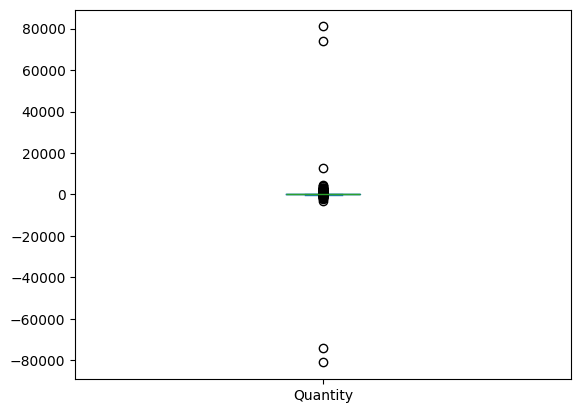

In [ ]:
df['Quantity'].plot(kind='box') # melihat dari visualisasi boxplot

Mengecek lower bound dan up boundary-nya

In [ ]:
q1 = df['Quantity'].quantile(0.25)
q3 = df['Quantity'].quantile(0.75)
iqr = q3-q1

up_bound = q3 + 1.5*iqr
low_bound = q1 - 1.5*iqr

print(f'Upper Boundary: {up_bound:.2f}' )
print(f'Lower Boundary: {low_bound:.2f}')

Upper Boundary: 26.00
Lower Boundary: -14.00


Handling outlier

In [ ]:
outlier_quantity = df['Quantity'][(df['Quantity']<low_bound) | (df['Quantity']>up_bound)]
print(f'Percentage of outliers: {len(outlier_quantity)*100/len(df['Quantity']):.2f}%%')

df['Quantity'] = df['Quantity'][(df['Quantity']>=low_bound) & (df['Quantity']<=up_bound)]

Percentage of outliers: 5.29%%


/tmp/ipykernel_2423/1699577665.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = df['Quantity'][(df['Quantity']>=low_bound) & (df['Quantity']<=up_bound)]


<Axes: >

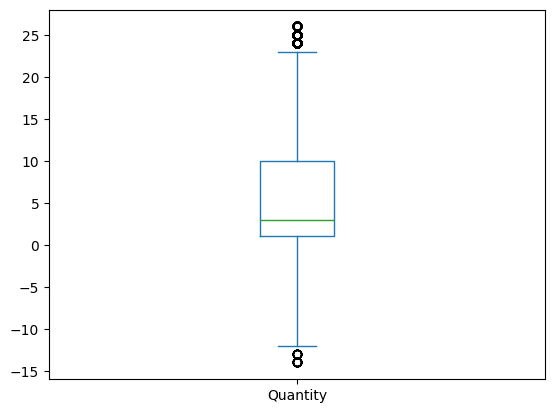

In [ ]:
df['Quantity'].plot(kind='box') # mengecek kembali dari visualisasi boxplot

##### Column `Revenue`

<Axes: >

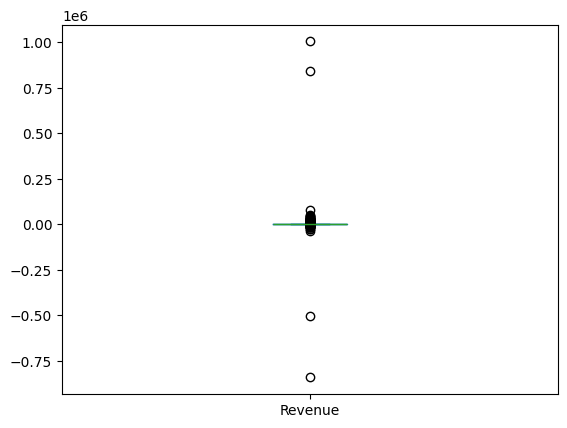

In [ ]:
df['Revenue'].plot(kind='box') # melihat dari visualisasi boxplot

Mengecek lower bound dan up boundary-nya

In [ ]:
q1 = df['Revenue'].quantile(0.25)
q3 = df['Revenue'].quantile(0.75)
iqr = q3-q1

up_bound = q3 + 1.5*iqr
low_bound = q1 - 1.5*iqr

print(f'Upper Boundary: {up_bound:.2f}' )
print(f'Lower Boundary: {low_bound:.2f}')

Upper Boundary: 274.23
Lower Boundary: -138.65


Handling outlier

In [ ]:
outlier_revenue = df['Revenue'][(df['Revenue']<low_bound) | (df['Revenue']>up_bound)]
print(f'Percentage of outliers: {len(outlier_revenue)*100/len(df['Revenue']):.2f}%%')

df['Revenue'] = df['Revenue'][(df['Revenue']>=low_bound) & (df['Revenue']<=up_bound)]

Percentage of outliers: 6.97%%


/tmp/ipykernel_2423/3891775209.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue'] = df['Revenue'][(df['Revenue']>=low_bound) & (df['Revenue']<=up_bound)]


<Axes: >

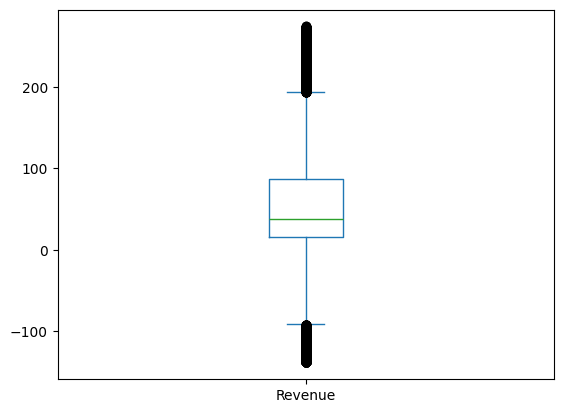

In [ ]:
df['Revenue'].plot(kind='box') # melihat dari visualisasi boxplot

#### Missing Values

Setelah handling outlier, kembali mengecek apakah ada missing value

In [ ]:
df.isna().sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,52458
Quantity,26148
CustomerNo,0
Country,0
Revenue,34430
Cancellation,0


Ternyata terdapat beberapa baris yang memiliki missing value setelah handling outlier, maka kita akan drop baris tersebut

In [ ]:
df = df.dropna()

In [ ]:
df.isna().sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,0
Country,0
Revenue,0
Cancellation,0


Data sudah tidak ada missing value

In [ ]:
df.info() # mengecek kembali informasi data

<class 'pandas.core.frame.DataFrame'>
Index: 409031 entries, 2 to 494254
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  409031 non-null  object        
 1   Date           409031 non-null  datetime64[ns]
 2   ProductNo      409031 non-null  object        
 3   ProductName    409031 non-null  object        
 4   Price          409031 non-null  float64       
 5   Quantity       409031 non-null  float64       
 6   CustomerNo     409031 non-null  object        
 7   Country        409031 non-null  object        
 8   Revenue        409031 non-null  float64       
 9   Cancellation   409031 non-null  bool          
 10  Day            409031 non-null  object        
 11  Month          409031 non-null  object        
 12  Year           409031 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(3), object(8)
memory usage: 41.0+ MB


Terdapat tipe data yang belum sesuai yaitu column `Quantity` yang seharusnya integer, maka kita akan ubah tipe data tersebut

In [ ]:
df['Quantity'] = df['Quantity'].astype(int) # mengubah tipe data menjadi integer

/tmp/ipykernel_2423/2457375821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = df['Quantity'].astype(int) # mengubah tipe data menjadi integer


In [ ]:
df.info() # mengecek kembali informasi dari data

<class 'pandas.core.frame.DataFrame'>
Index: 409031 entries, 2 to 494254
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  409031 non-null  object        
 1   Date           409031 non-null  datetime64[ns]
 2   ProductNo      409031 non-null  object        
 3   ProductName    409031 non-null  object        
 4   Price          409031 non-null  float64       
 5   Quantity       409031 non-null  int64         
 6   CustomerNo     409031 non-null  object        
 7   Country        409031 non-null  object        
 8   Revenue        409031 non-null  float64       
 9   Cancellation   409031 non-null  bool          
 10  Day            409031 non-null  object        
 11  Month          409031 non-null  object        
 12  Year           409031 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 41.0+ MB


### v. Analisis dan perhitungan

#### Visualisasi Data

Setelah United Kingdom, negara mana dengan transaksi terbanyak?

In [ ]:
mostTransaction = df.groupby('Country').agg({'TransactionNo':'count'}) # grouping untuk kolom Country dan count dari TransactionNo

top5mostTransaction = mostTransaction.sort_values(by='TransactionNo', ascending=False) # mengurutkan dari hasil grouping yaitu dari total count terbanyak
excUK = top5mostTransaction.iloc[1:6] # diambil dari index 1-6 yaitu menghilangkan index 1 yaitu United Kingdom
excUK

,TransactionNo
Country,
France,8076
Germany,7984
EIRE,5621
Spain,1897
Switzerland,1768


<Axes: title={'center': 'Transaction Count by Country'}, xlabel='Country', ylabel='Count of Transaction'>

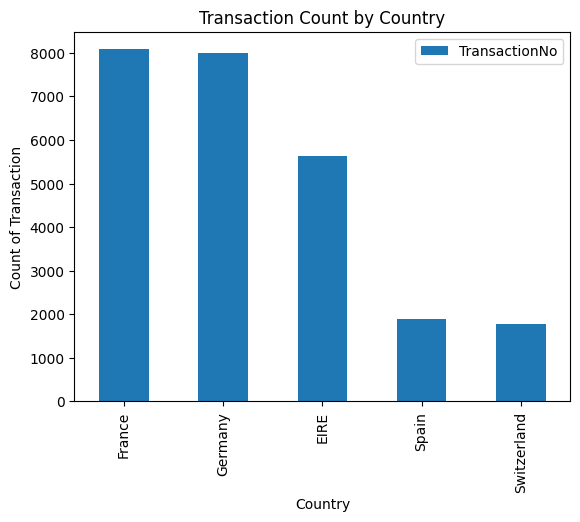

In [ ]:
excUK.plot(kind='bar', xlabel='Country', ylabel='Count of Transaction', title='Transaction Count by Country') # visualisasi menggunakan bar chart

Dari hasil visualisasi didaptkan bahwa 5 negara dengan total transaksi terbanyak setelah United Kingdom yaitu France, Germany, EIRE, Spain, dan Switzerland. Untuk target perluasan penjualan international bisa menargetkan ke 5 negara tersebut pada langkah awalnya.

Produk apa yang paling banyak terjual?


In [ ]:
mostProduct = df.groupby('ProductName').agg({'Quantity':'sum'}) # grouping kolom ProductName dan Jumlah Quantity
top5MostProduct = mostProduct.sort_values(by='Quantity', ascending=False).head() # mengurutkan hasil grouping dari jumlah quantity terbanyak dan diambil 5 teratasnya
top5MostProduct

,Quantity
ProductName,
Pack Of 72 Retrospot Cake Cases,15280
Jumbo Bag Red Retrospot,10863
Assorted Colour Bird Ornament,10389
Cream Hanging Heart T-Light Holder,9664
Popcorn Holder,9268


<Axes: title={'center': 'Total Quantity by Product Name'}, xlabel='Total of Quantity', ylabel='Product Name'>

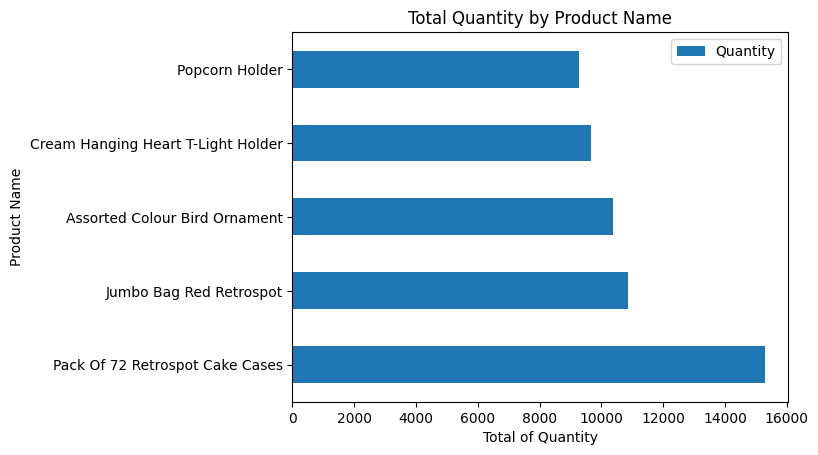

In [ ]:
top5MostProduct.plot(kind='barh', xlabel='Total of Quantity', ylabel='Product Name', title='Total Quantity by Product Name') # visualisasi menggunakan bar chart horizontal

Dari hasil visualisasi didapatkan hasil bahwa produk dengan total penjualan terbanyak menurut jumlah quantitynya adalah
1. Pack Of 72 Retrospot Cake Cases
2. Jumbo Bag Red Retrospot
3. Assorted Colour Bird Ornament
4. Cream Hanging Heart T-Light Holder
5. Popcorn Holder

Hal ini dapat menjadi pertimbangan produk apa saja yang sebaiknya dijual dalam program ekspansi ke luar negeri.

Produk apa yang paling sering di cancel?

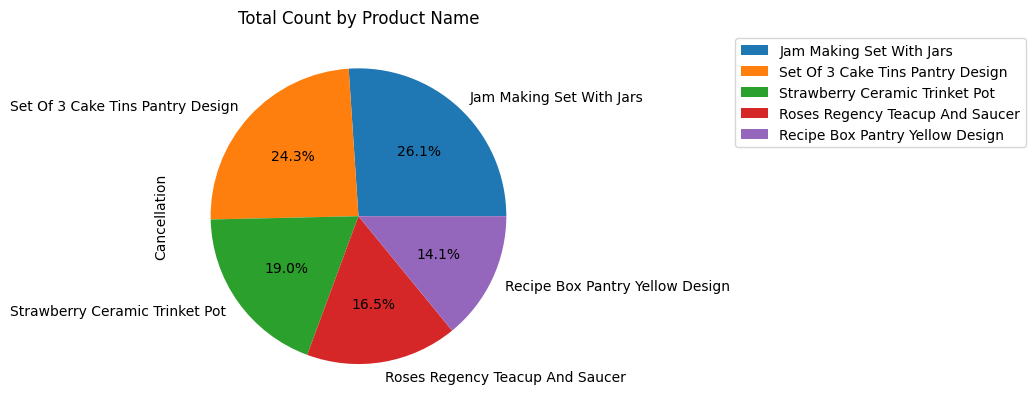

In [ ]:
mostCancelled = df[df['Cancellation'] == True].groupby('ProductName').agg({'Cancellation':'count'}) # grouping kolom ProductName dengan total product yang dicancel
mostCancelled = mostCancelled.sort_values(by='Cancellation', ascending=False).head() # mengurutkan hasil grouping dari total cancel terbanyak dan diambil 5 teratas
mostCancelled.plot(kind='pie', y='Cancellation', title ='Total Count by Product Name',autopct='%1.1f%%') # visualisasi menggunakan pie chart
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper left')

Dari hasil visualisasi didapatkan bahwa produk yang paling banyak di cancel yaitu Jam Making Set With Jars, Set of 3 Cake Tins Pantry Design, Strawberry Ceramic Trinket Pot, Roses Regency Teacup and Saucer, dan Recipe Box Pantry Yellow Design. Pembatalan tersebut disebabkan oleh kehabisan stok pada beberapa produk. Dalam situasi seperti ini, pelanggan cenderung membatalkan pesanan karena mereka ingin semua produk dikirimkan sekaligus. Mungkin bisa dilakukan evaluasi agar selalu memastikan barang yang di display pada e-commerse selalu on stock sehingga mengurangi pembatalan transaksi yang dilakukan oleh pelanggan.

Berapa banyak transaksi yang di cancel pada bulan April?

In [ ]:
df_april = df[df['Month'].str.contains('April')] # mengambil data yang kolom Month nya merupakan bulan April

cancelApril = df_april[df_april['Cancellation'] == True].groupby('Month').agg({'Cancellation':'count'}) # grouping kolom Month April dengan total transaksi yang di cancel
cancelApril

,Cancellation
Month,
April,374


Dari hasil grouping didapatkan hasil bahwa pada bulan April terdapat 366 transaksi yang melakukan pembatalan pesanan. Sekarang mari kita lihat apakah bulan April merupakan bulan dengan total transaksi terbanyak atau terendah atau tidak keduanya. Jika tidak bulan April, pada bulan apa transaksi yang dibatalkan paling banyak dilakukan.

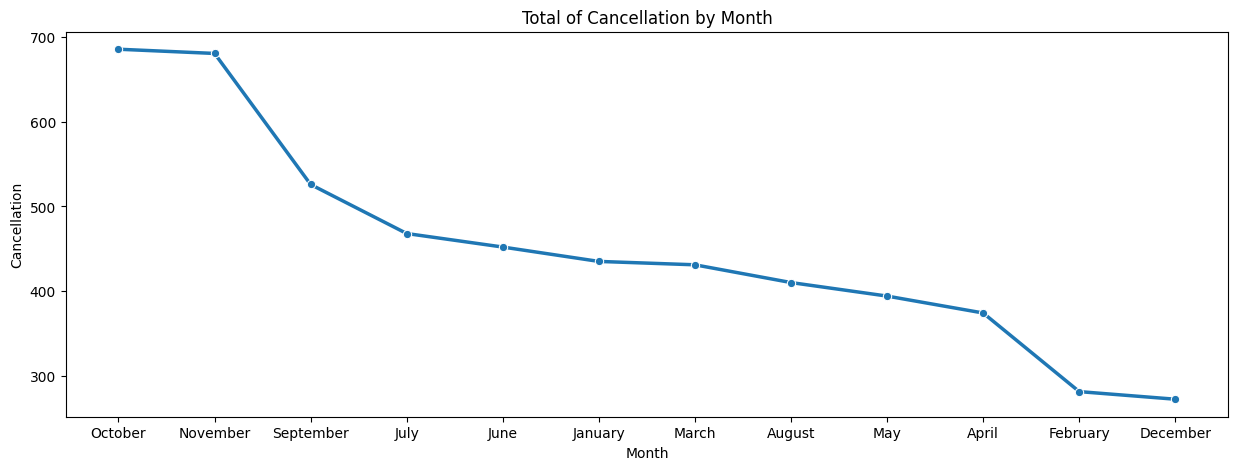

In [ ]:
cancelMonth = df[df['Cancellation'] == True].groupby('Month').agg({'Cancellation':'count'}) # grouping kolom Month dengan total transaksi yang di cancel
cancelMonth = cancelMonth.sort_values(by='Cancellation', ascending=False) # mengurutkan dari total transaksi yang paling banyak

plt.figure(figsize=(15, 5)) # mengatur ukuran chartnya dengan lebar 15 dan tinggi 5
sns.lineplot(x='Month', y='Cancellation', data=cancelMonth, marker='o', linewidth=2.5)
plt.title('Total of Cancellation by Month')
plt.show()

Dari hasil visualisasi terlihat bahwa bulan April bukan merupakan bulan dengan transaksi dengan total transaksi dibatalkan paling banyak atau paling rendah. Transaksi paling banyak dibatalkan terjadi pada bulan Oktober, sedangkan paling sedikit dibatalkan terjadi pada bulan Desember. Untuk kedepannya bisa digunakan strategi marketing promosi atau semacamnya untuk meningkatkan transaksi pada bulan-bulan dengan transaksi paling banyak di cancel.

#### Statistik Deskriptif (Mean)

Pada hari apa rata-rata revenue terbesar?

In [ ]:
mostRevenue = df.groupby('Day').agg({'Revenue':'mean'}) # melakukan grouping kolom Day dengan rata-rata revenue setiap harinya
mostRevenue.sort_values(by='Revenue', ascending=False) # mengurutkan hari dengan rata-rata revenue terbanyak

,Revenue
Day,
Sunday,69.287086
Monday,67.585613
Saturday,65.596228
Friday,63.470060
Thursday,62.503332
Wednesday,57.417763


Dari hasil perhitungan statistik deskriptif yaitu mean, didapatkan hasil bahwa rata-rata revenue terbanyak pada hari Minggu, dan paling rendah pada hari Rabu, sedangkan pada hari Selasa tidak ada satupun transaksi. Untuk kedepannya apabila akan launching produk baru bisa dilakukan di hari Minggu, dikarenakan banyaknya orang yang melakukan transaksi pada hari tersebut sehingga akan menarik lebih banyak pelanggan.

#### Statistik Inferensial (ANOVA)

Apakah terdapat perbedaan secara signifikan rata-rata penghasil revenue di antara negara France, Germany dan Spain?

In [ ]:
df['Country'].unique() # melihat penulisan negara yang terdapat dalam data

array(['United Kingdom', 'Norway', 'Belgium', 'Germany', 'France',
       'Austria', 'EIRE', 'USA', 'Channel Islands', 'Netherlands',
       'Iceland', 'Portugal', 'Spain', 'Italy', 'Greece', 'Japan',
       'Denmark', 'Finland', 'Cyprus', 'Switzerland', 'Australia',
       'Sweden', 'Malta', 'Poland', 'Hong Kong', 'Singapore', 'RSA',
       'Czech Republic', 'Israel', 'Unspecified', 'United Arab Emirates',
       'Canada', 'European Community', 'Bahrain', 'Brazil',
       'Saudi Arabia', 'Lebanon'], dtype=object)

In [ ]:
germany = df['Revenue'][(df['Country']=='Germany')] # mengambil data dengan negara Germany
france = df['Revenue'][(df['Country']=='France')] # mengambil data dengan negara France
spain = df['Revenue'][(df['Country']=='Spain')] # mengambil data dengan negara Spain

H0: Tidak ada perbedaan yang signifikan rata-rata revenue antara 3 negara tersebut

H1: Terdapat perbedaan yang signifikan rata-rata revenue antara 3 negara tersebut

In [ ]:
res = stats.f_oneway(germany, france, spain) # dengan menggunakan library stat untuk melakukan perhitungan statistik inferensial dengan metode ANOVA
print('P-value:',res.pvalue)

P-value: 4.537504580793822e-17


Nilai p lebih dari 0,05, sehingga hipotesis nol (H0) diterima, yang berarti rata-rata revenue pada negara Germany, France, dan Spain tidak berbeda secara signifikan.

Ketiga negara tersebut memiliki rata-rata revenue yang tidak jauh berbeda secara signifikan. Hal ini bisa dikatakan bahwa penjualan saat ini sudah merata berdasarkan transaksi luar negeri.

### vi. Pengambilan Kesimpulan

Dari hasil analisa yang tilah dilakukan dapat disimpulkan bahwa :
- Apabila ingin melakukan ekspansi, 5 negara yang menjadi target utama yaitu France, Germany, EIRE, Spain, dan Switzerland
- Dari hasil perbandingan rata-rata revenue dari 3 negara (France, Germany, dan Spain) didapatkan bahwa saat ini tidak ada perbedaan secara signifikan antara ketiganya dan bisa dikatakan sudah merata untuk rata-rata revenuenya.
- Total penjualan terbanyak menurut jumlah quantitynya antara lain Pack Of 72 Retrospot Cake Cases, Jumbo Bag Red Retrospot, Assorted Colour Bird Ornament, Cream Hanging Heart T-Light Holder, dan Popcorn Holder. Hal ini dapat menjadi pertimbangan produk apa saja yang sebaiknya dijual dalam program ekspansi ke luar negeri.
- Produk yang paling banyak di cancel yaitu Jam Making Set With Jars, Set of 3 Cake Tins Pantry Design, Strawberry Ceramic Trinket Pot, Roses Regency Teacup and Saucer, dan Recipe Box Pantry Yellow Design. Hal ini menjadi perhatian karena pembatalan tersebut disebabkan oleh kehabisan stok pada produk. Mungkin bisa dilakukan evaluasi lanjut untuk selalu memastikan stock di e-commerce sesuai dengan yang tersedia di gudang.
- Rata-rata revenue terbanyak pada hari Minggu, dan paling rendah pada hari Rabu, sedangkan pada hari Selasa tidak ada satupun transaksi. Untuk kedepannya apabila akan launching produk baru dapat dilakukan di hari Minggu, dikarenakan banyaknya pelanggan yang melakukan transaksi pada hari tersebut sehingga akan menarik lebih banyak pelanggan.
- Transaksi paling banyak dibatalkan terjadi pada bulan Oktober 2019, sedangkan paling sedikit dibatalkan terjadi pada bulan Desember 2019. Untuk kedepannya bisa digunakan strategi marketing promosi atau semacamnya untuk meningkatkan transaksi pada bulan-bulan dengan transaksi paling banyak di cancel.

In [ ]:
df.to_csv('sales_cleaned_final.csv') # menyimpan dataset yang sudah clean